<a href="https://colab.research.google.com/github/Afrinjahan/machine_learning/blob/main/ML_Lab04_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning — Lab Sheet 04
## Implementing Simple & Multiple Linear Regression (Auto MPG Dataset)

**Brahmaputra International University | Department of CSE**

**Objectives:**
- Implement Simple Linear Regression using a single predictor variable.
- Implement Multiple Linear Regression using several predictor variables.
- Evaluate regression models using MAE, MSE, RMSE, and R² score.
- Interpret regression coefficients and visualize model fit and residuals.
- Compare the performance of simple vs. multiple regression on the same target variable.

**Dataset:** Auto MPG — real fuel-economy data for 398 cars (UCI Machine Learning Repository).

### 0. Setup

In [ ]:
!pip install -q scikit-learn pandas matplotlib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### 1. Load and Prepare the Data

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
print(df.shape)
print(df.isnull().sum())


(398, 9)
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [ ]:
# Drop the rows with missing horsepower
df = df.dropna(subset=['horsepower']).reset_index(drop=True)
print('Shape after cleaning:', df.shape)
df.head()


Shape after cleaning: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### 2. Simple Linear Regression (Horsepower → MPG)

In [ ]:
X = df[['horsepower']]
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)
y_pred = lr_simple.predict(X_test)

print(f'Coefficient: {lr_simple.coef_[0]:.4f}')
print(f'Intercept: {lr_simple.intercept_:.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.3f}')
print(f'MSE:  {mean_squared_error(y_test, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.3f}')


Coefficient: -0.1626
Intercept: 40.6061
MAE:  3.783
MSE:  22.153
RMSE: 4.707
R2 Score: 0.566


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


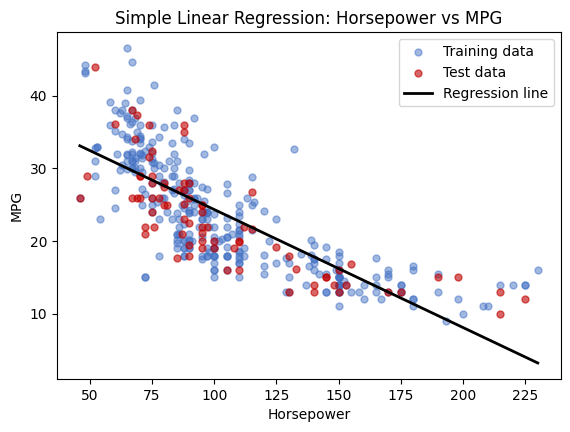

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(X_train, y_train, alpha=0.5, color='#4472C4', label='Training data', s=25)
ax.scatter(X_test, y_test, alpha=0.6, color='#C00000', label='Test data', s=25)
x_line = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 100).reshape(-1,1)
ax.plot(x_line, lr_simple.predict(x_line), color='black', linewidth=2, label='Regression line')
ax.set_title('Simple Linear Regression: Horsepower vs MPG')
ax.set_xlabel('Horsepower'); ax.set_ylabel('MPG'); ax.legend()
plt.show()


**Interpretation:** MPG = 40.61 − 0.163 × Horsepower. Every additional unit of horsepower is associated with a decrease of about 0.16 mpg. The model explains 56.6% of the variance (R² = 0.566) using horsepower alone.

### 3. Residual Analysis

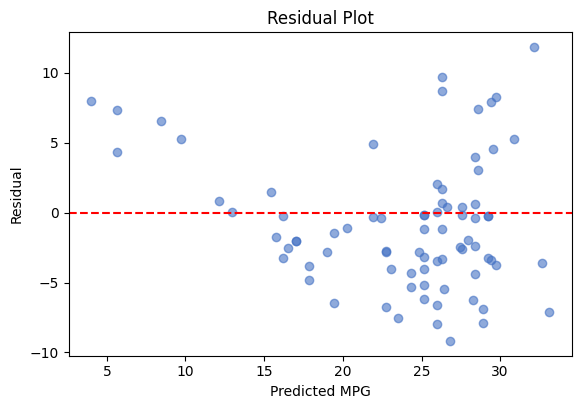

In [ ]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(y_pred, residuals, alpha=0.6, color='#4472C4')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted MPG'); ax.set_ylabel('Residual')
ax.set_title('Residual Plot')
plt.show()


**Observation:** Residuals show a slight curve rather than random scatter around zero — the true horsepower–MPG relationship is not perfectly linear (addressed with Polynomial Regression in Lab 5).

### 4. Multiple Linear Regression

In [ ]:
features = ['cylinders','displacement','horsepower','weight','acceleration']
X_multi = df[features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_multi, y, test_size=0.2, random_state=42)

lr_multi = LinearRegression()
lr_multi.fit(X_train2, y_train2)
y_pred2 = lr_multi.predict(X_test2)

for f, c in zip(features, lr_multi.coef_):
    print(f'  {f}: {c:.4f}')
print(f'Intercept: {lr_multi.intercept_:.4f}')
print(f'MAE:  {mean_absolute_error(y_test2, y_pred2):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test2, y_pred2)):.3f}')
print(f'R2 Score: {r2_score(y_test2, y_pred2):.3f}')


  cylinders: -0.1758
  displacement: -0.0067
  horsepower: -0.0489
  weight: -0.0050
  acceleration: -0.0604
Intercept: 46.8371
MAE:  3.486
RMSE: 4.235
R2 Score: 0.649


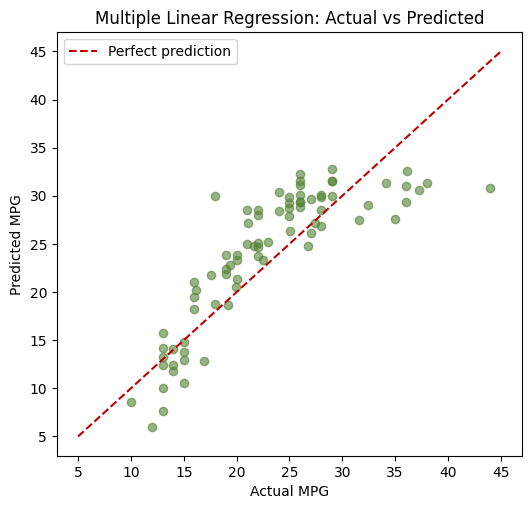

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(y_test2, y_pred2, alpha=0.6, color='#548235')
lims = [min(y_test2.min(), y_pred2.min())-1, max(y_test2.max(), y_pred2.max())+1]
ax.plot(lims, lims, color='#C00000', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual MPG'); ax.set_ylabel('Predicted MPG')
ax.set_title('Multiple Linear Regression: Actual vs Predicted')
ax.legend()
plt.show()


### 5. Compare Simple vs. Multiple Regression

In [ ]:
print(f'Simple LR   (horsepower only): R2 = {r2_score(y_test, y_pred):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')
print(f'Multiple LR (5 features):      R2 = {r2_score(y_test2, y_pred2):.3f}, RMSE = {np.sqrt(mean_squared_error(y_test2, y_pred2)):.3f}')


Simple LR   (horsepower only): R2 = 0.566, RMSE = 4.707
Multiple LR (5 features):      R2 = 0.649, RMSE = 4.235


**Conclusion:** Multiple Linear Regression improves R² from 0.566 to 0.649 and reduces RMSE by ~0.47 mpg — adding weight, displacement, cylinders, and acceleration captures more variance than horsepower alone.

### 6. Lab Exercise (To Be Submitted)

1. Add `model_year` as a sixth predictor. Does R² improve? Explain why a newer model year might be associated with higher MPG.
2. One-hot encode `origin` and add it to the model. Report the new R² and RMSE.
3. Standardize the 5 numeric features using `StandardScaler` before fitting. Do the coefficients change? Does performance change? Explain why or why not.
4. Plot a correlation heatmap of all numeric features. Which two predictors are most strongly correlated, and why might that matter for interpreting coefficients?
5. Save your completed notebook and submit it (.ipynb) with all code, outputs, and answers added as new cells.